In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Mall_Customers.csv")

In [3]:
df


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


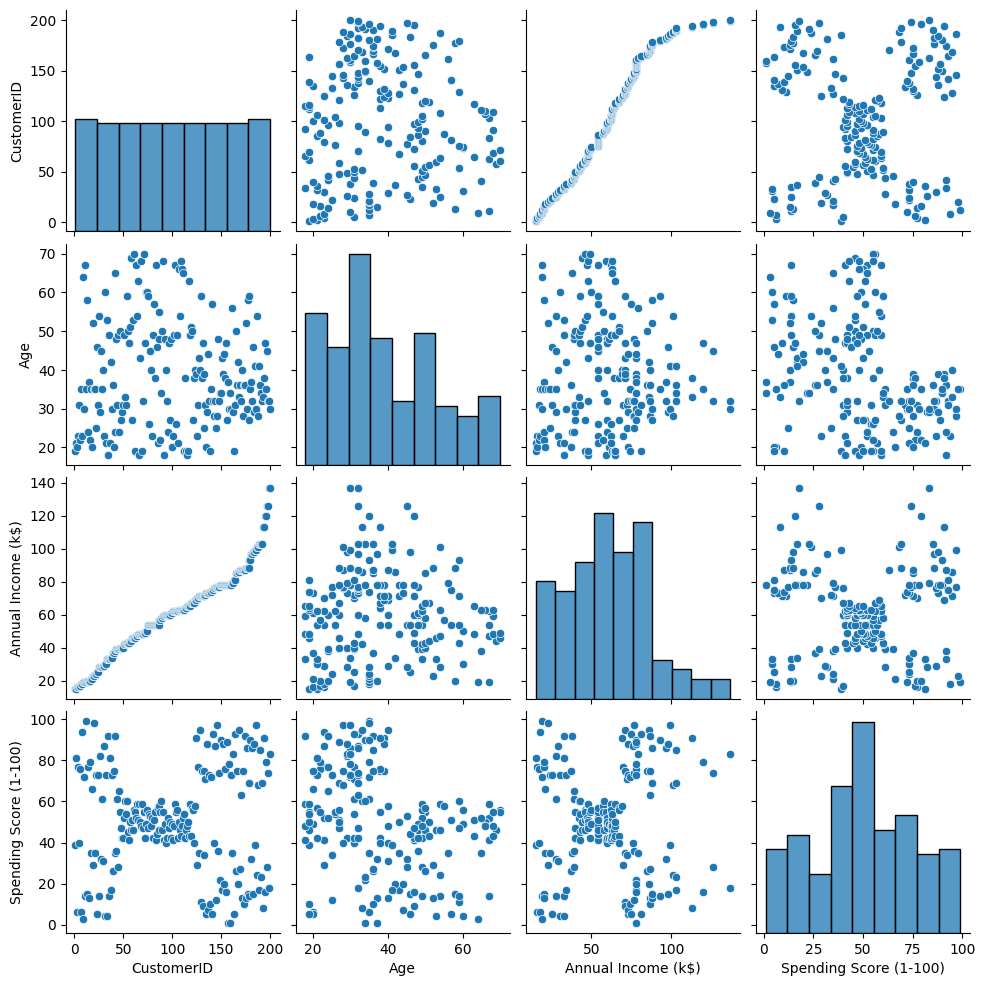

In [4]:
sns.pairplot(df)

### Feature and Response

In [5]:
x=df.iloc[:,[3,4]]

In [6]:
x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Dendrogram

In [7]:
from scipy.cluster import hierarchy as hi

In [8]:
d=hi.linkage(x,method="ward")

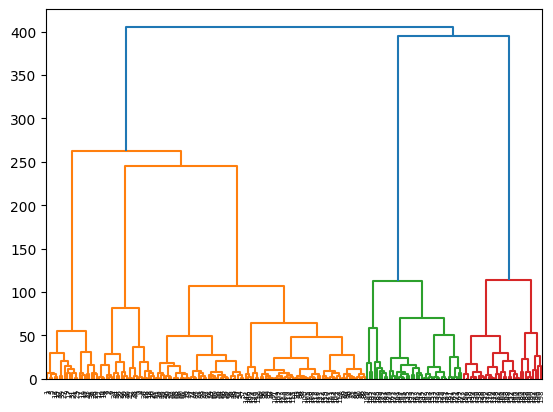

In [9]:
hi.dendrogram(d)
plt.show()

### Model preparation

In [10]:
from sklearn.cluster import AgglomerativeClustering

In [11]:
agg=AgglomerativeClustering(n_clusters=5)

In [12]:
y=agg.fit_predict(x)

In [13]:
y

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

### Add this as an Target

In [14]:
df["Target"]=y

In [15]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Target
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


#### groupby

In [16]:
df.groupby("Target")[["Annual Income (k$)","Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Target,,
0,89.406250,15.593750
1,55.811765,49.129412
2,86.538462,82.128205
3,25.095238,80.047619
4,26.304348,20.913043


### classification

## Supervise leaning

In [17]:
df.drop("CustomerID",axis=1,inplace=True)

In [18]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Target
0,Male,19,15,39,4
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,4


### Encoding

In [19]:
from sklearn.preprocessing import OrdinalEncoder

In [20]:
ord=OrdinalEncoder()
col=df.select_dtypes(object).columns

In [21]:
col

Index(['Genre'], dtype='str')

In [22]:
df[col]=ord.fit_transform(df[col])
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Target
0,1.0,19,15,39,4
1,1.0,21,15,81,3
2,0.0,20,16,6,4
3,0.0,23,16,77,3
4,0.0,31,17,40,4


### Feature and response

In [23]:
x = df.iloc[ : , :-1] # 2D
y = df.iloc[ : ,  -1]

### Train & test

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
xtrain, xtest, ytrain, ytest = train_test_split( x, y,  test_size=0.2, random_state=1)

#### model section

## KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
knn = KNeighborsClassifier()
knn.fit(xtrain, ytrain)

knnyp = knn.predict(xtest)

In [28]:
knntrain = knn.score(xtrain, ytrain)
knntest  = knn.score(xtest, ytest)

print(knntrain, "   ", knntest)

0.9875     0.975


### LogisticRegression

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
xtrain1, xtest1, ytrain1, ytest1   = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

In [31]:
logreg = LogisticRegression()

logreg.fit(xtrain1, ytrain1)

yp  =  logreg.predict(xtest1)

In [32]:
logregtrain = logreg.score(xtrain1, ytrain1)
logregtest  = logreg.score(xtest1, ytest1)

print(logregtrain, "   ", logregtest)

0.89375     0.8


### SVM

In [33]:
from sklearn.svm import SVC

In [34]:
svm = SVC()

svm.fit(xtrain, ytrain)

svmyp = svm.predict(xtest)

In [35]:
svmtrain = svm.score(xtrain, ytrain)
svmtest  = svm.score(xtest, ytest)

print( svmtrain, "   ", svmtest)

0.99375     0.975


### RandomForest

In [36]:
from sklearn.ensemble  import RandomForestRegressor

In [37]:
rf=  RandomForestRegressor()
rf.fit(xtrain,ytrain)



print(rf.score(xtrain,ytrain))
print(rf.score(xtest,ytest))

0.9910274566473989
0.9460275449101796


In [38]:
Genre = float(input("Enter No of Genre "))
Age = int(input("Enter Age "))
Annual_Income = int(input("Enter Annual Income (k$) "))
Spending_Score = int(input("Enter Spending Score (1-100) "))
result = rf.predict([[Genre, Age, Annual_Income, Spending_Score ]])

print(result[0])

Enter No of Genre  1
Enter Age  1
Enter Annual Income (k$)  1
Enter Spending Score (1-100)  1


3.95


### model evalution

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", r2_score(ytest, yp))
print("MAE :", mean_absolute_error(ytest, yp))
print("MSE :", mean_squared_error(ytest, yp))
print("RMSE :", np.sqrt(mean_squared_error(ytest, yp)))

R2 Score : -0.7365269461077844
MAE : 1.375
MSE : 3.625
RMSE : 1.9039432764659772


In [40]:
df.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Target'],
      dtype='str')

In [41]:
Genre = float(input("Enter No of Genre "))
Age = int(input("Enter Age "))
Annual_Income = int(input("Enter Annual Income (k$) "))
Spending_Score = int(input("Enter Spending Score (1-100) "))
result = svm.predict([[Genre, Age, Annual_Income, Spending_Score ]])

print(result[0])

Enter No of Genre  1
Enter Age  1
Enter Annual Income (k$)  1
Enter Spending Score (1-100)  1


4


### DecisionTree

In [42]:
from sklearn.tree import DecisionTreeRegressor

In [43]:
dt = DecisionTreeRegressor()

dt.fit(xtrain, ytrain)

yp = dt.predict(xtest)

In [44]:
train = dt.score(xtrain, ytrain)
test  = dt.score(xtest, ytest)

print(train, "   ", test)

1.0     0.8802395209580838


### cross_val

In [45]:
from sklearn.model_selection import cross_val_score

In [46]:
cv = cross_val_score(DecisionTreeRegressor(), x, y, cv=4)
cv.mean()

np.float64(-0.9282228787558858)

### Bagging

In [47]:
from sklearn.ensemble  import BaggingRegressor

In [48]:
bag= BaggingRegressor(estimator= DecisionTreeRegressor() , n_estimators= 100)
bag.fit(xtrain,ytrain)
bag.predict(xtest)


print(bag.score(xtrain,ytrain))
print(bag.score(xtest,ytest))

0.9889470134874759
0.9157209580838324


In [49]:
Gender= float(input("Enter No of Gendre "))
Age = int(input("Enter Age "))
Annual_Income = int(input("Enter Annual Income (k$) "))
Spending_Score = int(input("Enter Spending Score (1-100) "))
result = bag.predict([[Genre, Age, Annual_Income, Spending_Score ]])

print(result[0])

Enter No of Gendre  1
Enter Age  1
Enter Annual Income (k$)  1
Enter Spending Score (1-100)  1


3.95


In [50]:
from sklearn.metrics  import     accuracy_score,  confusion_matrix, classification_report

In [51]:
ac = accuracy_score(ytest, yp)
cm = confusion_matrix(ytest, yp)
cr = classification_report(ytest, yp)

In [52]:
print(ac)
print(cm)
print(cr)

0.95
[[ 8  1  0  0  0]
 [ 0 13  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0  5  0]
 [ 0  1  0  0  7]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.87      1.00      0.93        13
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      0.88      0.93         8

    accuracy                           0.95        40
   macro avg       0.97      0.95      0.96        40
weighted avg       0.96      0.95      0.95        40



In [53]:
import pickle

In [54]:
with open("trainedmodel.pkl", mode="wb") as file:
    pickle.dump(svm,file)

In [55]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100),Target
0,1.0,19,15,39,4
1,1.0,21,15,81,3
2,0.0,20,16,6,4
3,0.0,23,16,77,3
4,0.0,31,17,40,4
...,...,...,...,...,...
195,0.0,35,120,79,2
196,0.0,45,126,28,0
197,1.0,32,126,74,2
198,1.0,32,137,18,0
